In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import TimeSeries

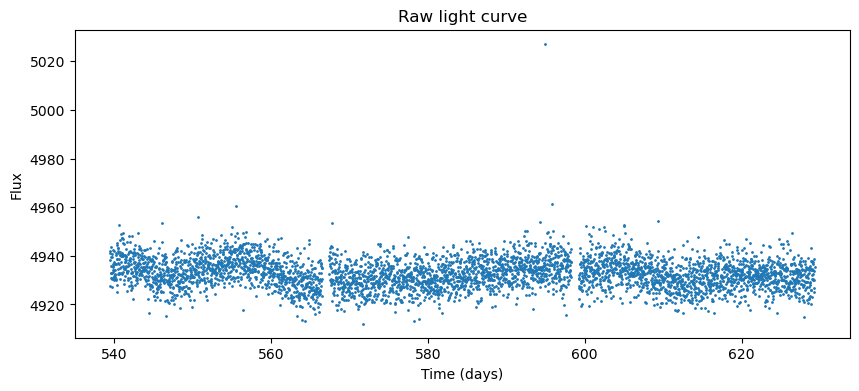

In [2]:
import os
os.chdir("/Users/adarsh/Downloads/")
hdul = fits.open("kplr007102366-2010265121752_llc.fits")
data = hdul[1].data

time = data["TIME"]
flux = data["PDCSAP_FLUX"]

plt.figure(figsize=(10,4))
plt.scatter(time, flux, s=1)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw light curve")
plt.show()

In [3]:
time_arr = np.array(time)
flux_arr = np.array(flux)

mask = np.isfinite(time_arr) & np.isfinite(flux_arr)

time_clean = time_arr[mask]
flux_clean = flux_arr[mask]

In [4]:
from scipy.signal import medfilt
flux64 = flux_clean.astype(np.float64)
smooth = medfilt(flux64, kernel_size=101)
flux_detrended = flux64 / smooth

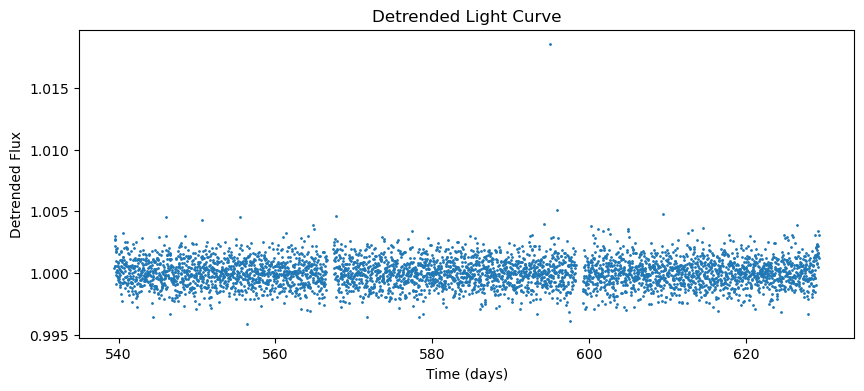

In [5]:
plt.figure(figsize=(10,4))
plt.scatter(time_clean, flux_detrended, s=1)
plt.xlabel("Time (days)")
plt.ylabel("Detrended Flux")
plt.title("Detrended Light Curve")
plt.show()

In [6]:
from scipy.signal import find_peaks
inv_flux = 1.0 - flux_detrended
peaks, props = find_peaks(inv_flux, prominence=0.0002)
transit_times = time_clean[peaks]
print("Number of candidate dips:", len(peaks))
print("First few dip times:", transit_times[:10])

Number of candidate dips: 1318
First few dip times: [539.51154408 539.61371434 539.67501655 539.73631876 539.77718699
 539.81805513 539.85892327 539.92022547 540.00196173 540.08369799]


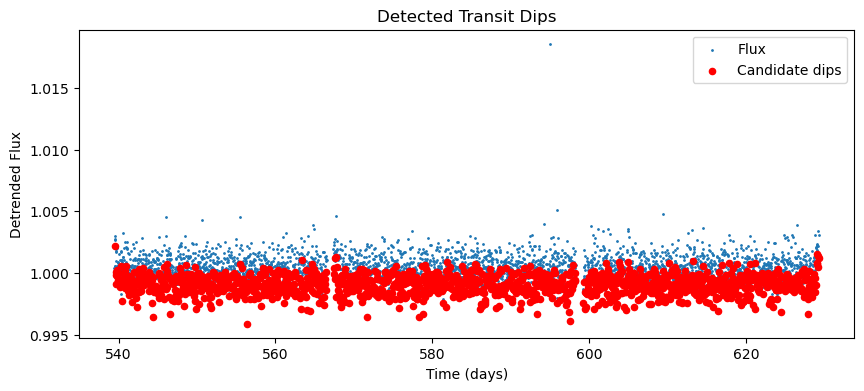

In [7]:
plt.figure(figsize=(10,4))
plt.scatter(time_clean, flux_detrended, s=1, label="Flux")
plt.scatter(time_clean[peaks], flux_detrended[peaks], color="red", s=20, label="Candidate dips")
plt.xlabel("Time (days)")
plt.ylabel("Detrended Flux")
plt.title("Detected Transit Dips")
plt.legend()
plt.show()

First few Δt values: [0.10217026 0.06130221 0.06130221 0.04086824 0.04086814 0.04086814
 0.0613022  0.08173627 0.08173626 0.06130229]


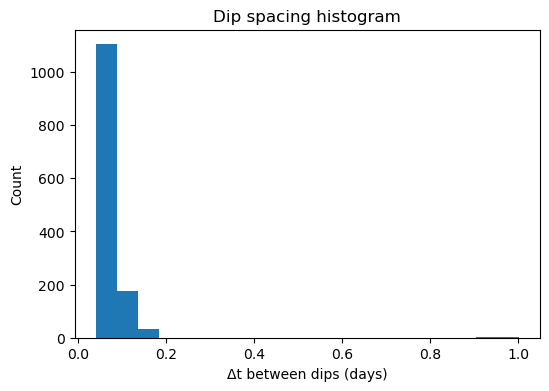

In [8]:
transit_times = np.sort(transit_times)
transit_difference = np.diff(transit_times)
print("First few Δt values:", transit_difference[:10])
plt.figure(figsize=(6,4))
plt.hist(transit_difference, bins=20)
plt.xlabel("Δt between dips (days)")
plt.ylabel("Count")
plt.title("Dip spacing histogram")
plt.show()

In [9]:
period_guess = np.median(transit_difference)
print("Rough period guess:", period_guess)

Rough period guess: 0.06130045750614954


In [12]:
from astropy.timeseries import BoxLeastSquares
x = time_clean
y = flux_detrended
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
periods = np.linspace(0.5 * period_guess, 1.5 * period_guess, 500)
bls = BoxLeastSquares(x, y)
result = bls.power(periods, 0.001)
best_idx = np.argmax(result.power)
best_period = result.period[best_idx]
best_initial_time = result.transit_time[best_idx]
print("Best period (days):", best_period)
print("Best initial transit time:", best_initial_time)

Best period (days): 0.04932291320384578
Best initial transit time: 539.481775838813


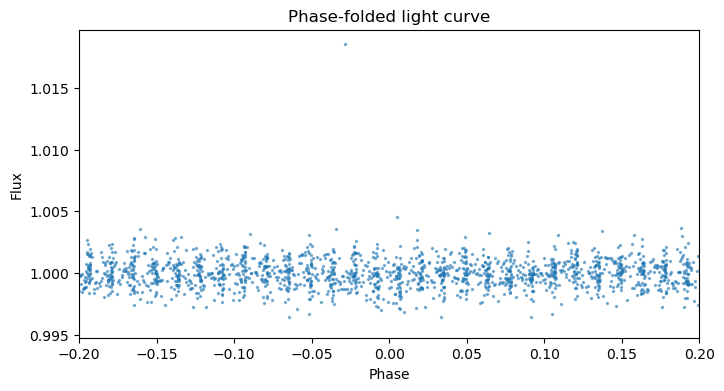

In [14]:
phase = ((x - best_initial_time) / best_period) % 1.0
phase[phase > 0.5] -= 1.0

plt.figure(figsize=(8,4))
plt.scatter(phase, y, s=2, alpha=0.5)
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Phase-folded light curve")
plt.xlim(-0.2, 0.2)
plt.show()

In [15]:
in_transit = np.abs(phase) < 0.03
out_transit = np.abs(phase) > 0.1
flux_in = y[in_transit]
flux_out = y[out_transit]
print("N in-transit:", flux_in.size)
print("N out-of-transit:", flux_out.size)

N in-transit: 253
N out-of-transit: 3415


In [16]:
baseline = np.median(flux_out)
in_level = np.median(flux_in)
depth = baseline - in_level
print("Transit depth (relative flux):", depth)

Transit depth (relative flux): 0.00025690916916187856


In [17]:
Rp_Rstar = np.sqrt(abs(depth))
print("Rp / Rstar =", Rp_Rstar)

Rp / Rstar = 0.016028386355521836


In [18]:
Rstar_Rearth = 109.0
Rp_Rearth = Rp_Rstar * Rstar_Rearth
print("Approx planet radius (Earth radii):", Rp_Rearth)

Approx planet radius (Earth radii): 1.7470941127518802
